<a href="https://colab.research.google.com/github/if8988118-iqra/Customer_Churn_ML/blob/main/Customer_Churn_ML_GREEKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📉 Customer Churn Prediction
---
> **Dataset:** Customer Churn Testing Dataset  
> **Goal:** Predict whether a customer will churn (leave) or not  
> **Target Variable:** `Churn` (1 = Churned, 0 = Not Churned)

---
## 📌 ML Lifecycle (GREEKS Framework)
| Phase | Full Name | What Happens |
|-------|-----------|--------------|
| **G** | Get Data | Collect & load data |
| **R** | Review Data | Explore & understand data (EDA) |
| **E** | Extract Features | Clean & engineer features |
| **E** | Evaluate Models | Train & compare ML models |
| **K** | Keep Best Model | Select & fine-tune best model |
| **S** | Serve / Score | Predict & interpret results |


---
## 📦 Phase 1 — Import Libraries
### 📖 Definition
Install and import all required Python libraries before starting any ML work.

### 🔍 What to Look For
- No import errors
- All libraries load successfully


In [4]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from sklearn.impute import SimpleImputer

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


### 📝 Observation
- All standard ML libraries are imported
- `warnings` are suppressed for clean output
- Libraries cover: data handling, visualization, preprocessing, modeling, evaluation


---
## Phase 2: Data Collection & Load
### 📖 Definition
The first step of any ML project. We load the raw dataset and take a first look at its structure — how many rows, columns, and what kind of data it contains.

### 🔍 What to Look For
- Shape of dataset (rows × columns)
- Column names and data types
- First few rows to understand the data
- Any obvious issues at first glance


In [5]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Machine_learning/customer_churn_dataset-testing-master.csv')

print("=" * 50)
print("📊 DATASET SHAPE")
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 50)
print("📋 COLUMN NAMES & DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("👀 FIRST 5 ROWS")
print("=" * 50)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 DATASET SHAPE
Rows    : 64,374
Columns : 12

📋 COLUMN NAMES & DATA TYPES
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

👀 FIRST 5 ROWS


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


### 📝 Observation
- Dataset has **64,374 rows** and **12 columns**
- Target column is `Churn` (binary: 0 or 1)
- Mix of numerical and categorical columns
- `CustomerID` is just an identifier — not useful for ML
- Columns like `Gender`, `Subscription Type`, `Contract Length` are categorical


---
## Phase 3: Exploratory Data Analysis
### 📖 Definition
EDA means exploring and understanding the data visually and statistically before building any model. We look at distributions, relationships, missing values, and class balance.

### 🔍 What to Look For
- Missing values (nulls)
- Class imbalance in target variable
- Distribution of numerical features
- Correlation between features
- Outliers


In [6]:
# 1. Basic Statistics
print("=" * 50)
print("📈 BASIC STATISTICS")
print("=" * 50)
df.describe()


📈 BASIC STATISTICS


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
# 2. Missing Values Check
print("=" * 50)
print("❓ MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
if missing.sum() == 0:
    print("✅ No missing values found!")


❓ MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ No missing values found!


🎯 TARGET VARIABLE — CHURN DISTRIBUTION
Not Churned (0): 33,881 (52.6%)
Churned     (1): 30,493 (47.4%)


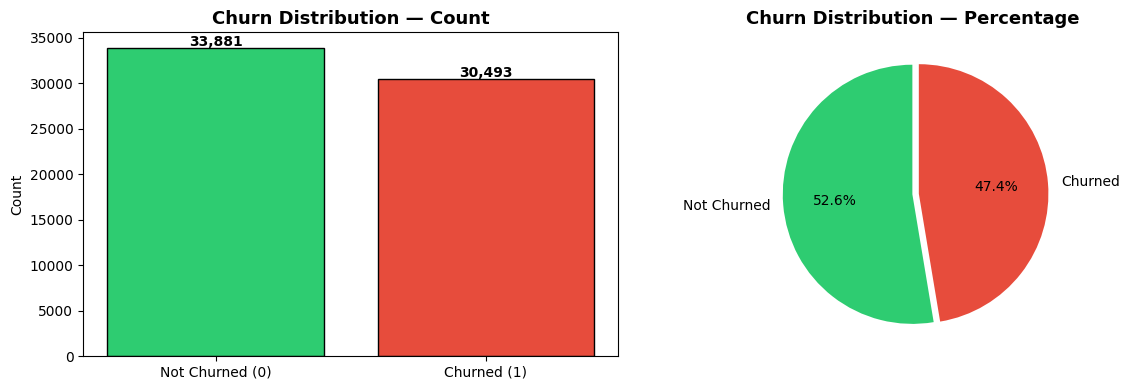

In [8]:
# 3. Target Variable Distribution
print("=" * 50)
print("🎯 TARGET VARIABLE — CHURN DISTRIBUTION")
print("=" * 50)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"Not Churned (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"Churned     (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Distribution — Percentage', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


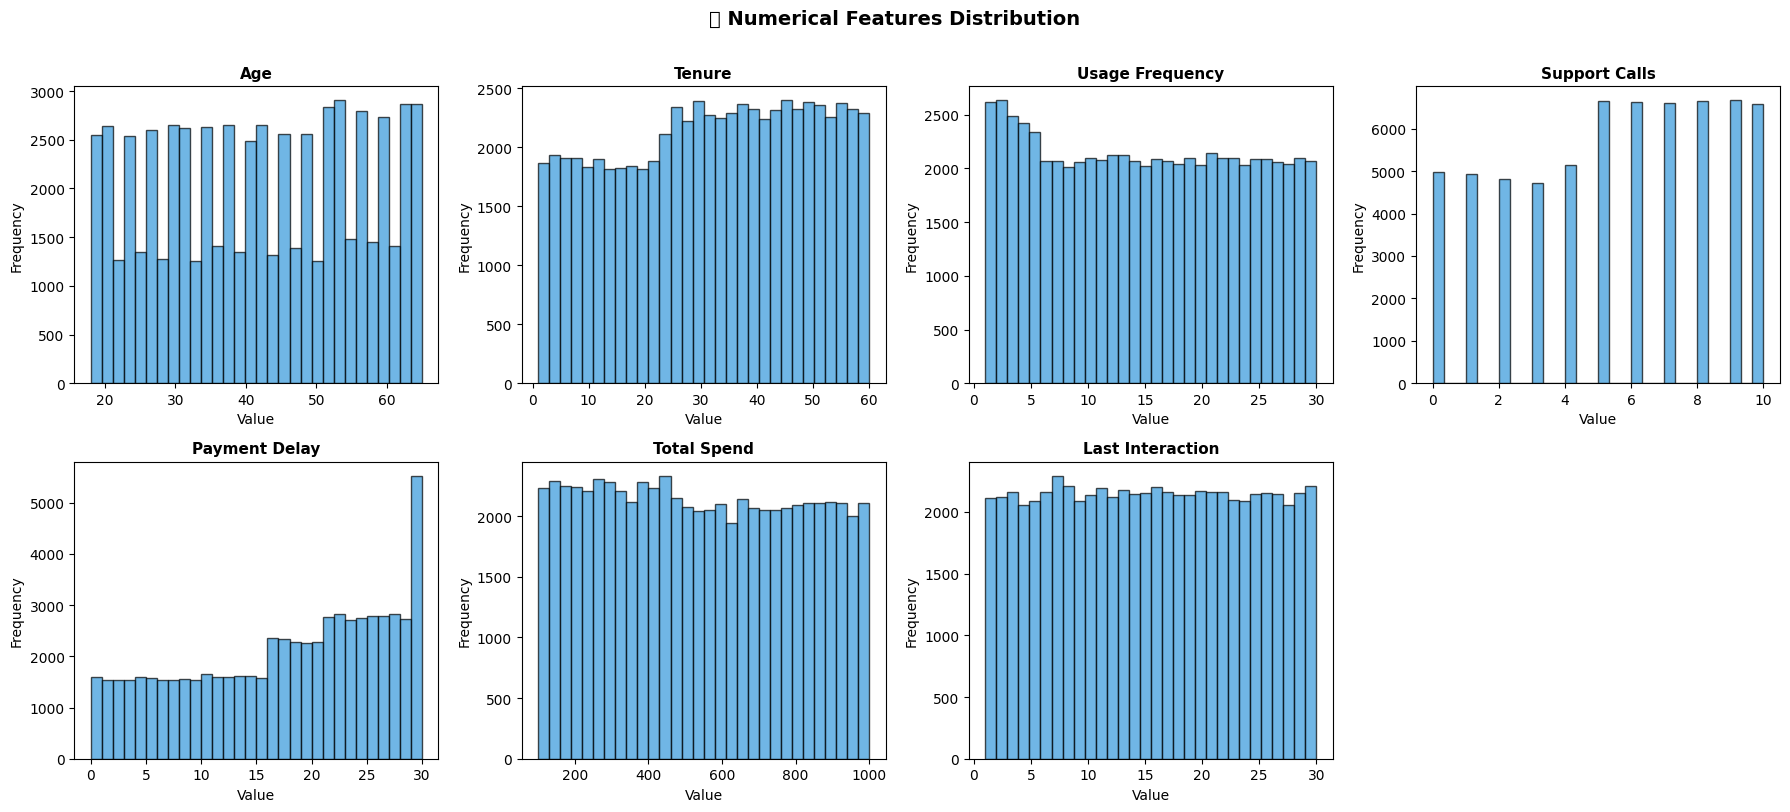

In [9]:
# 4. Numerical Features Distribution
numerical_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                  'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
plt.suptitle('📊 Numerical Features Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


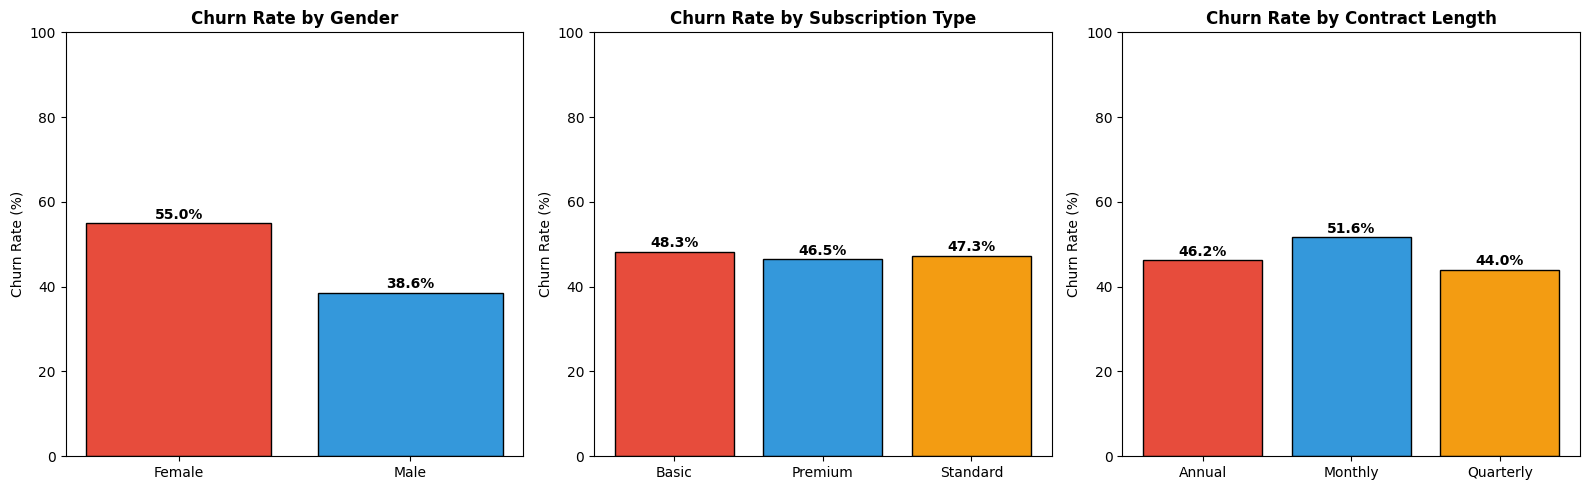

In [10]:
# 5. Categorical Features vs Churn
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=['#e74c3c', '#3498db', '#f39c12'][:len(churn_rate)],
                       edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 100)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


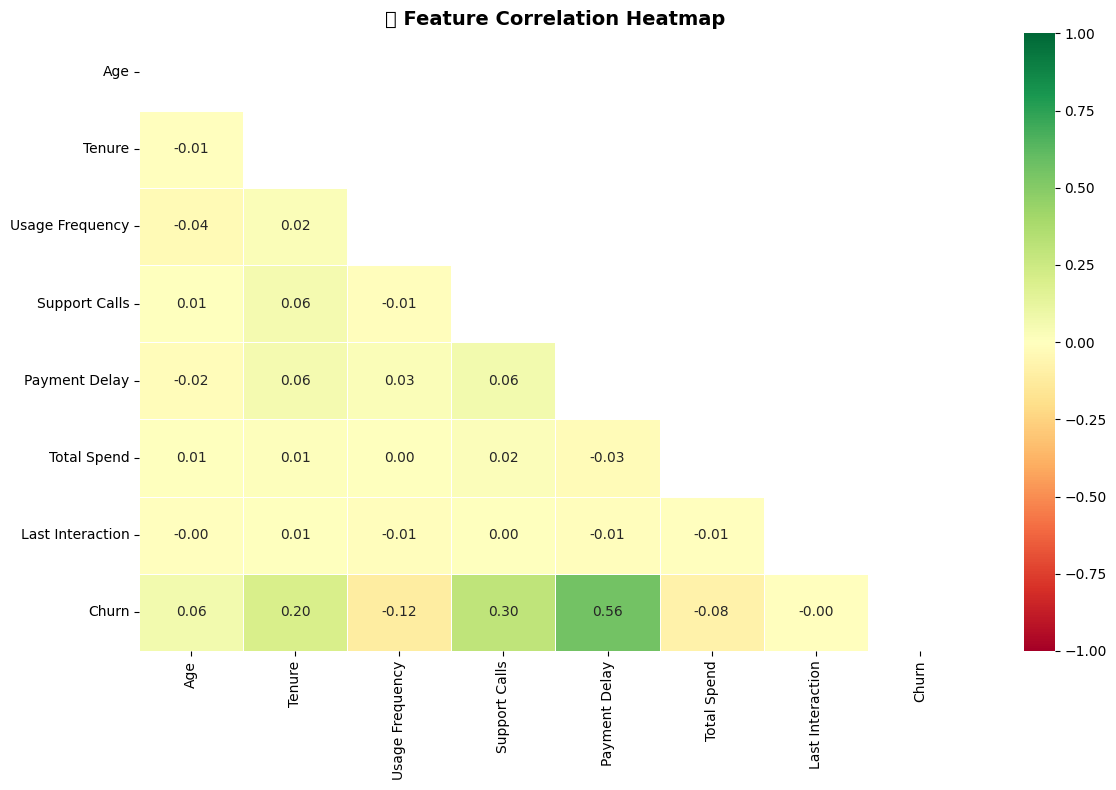

In [11]:
# 6. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
             'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('🔗 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 📝 Observation
- **Missing Values:** Dataset is clean — no missing values
- **Class Balance:** Check if churn is balanced or imbalanced
- **Support Calls & Payment Delay** likely have high correlation with churn
- **Contract Length** — Monthly contracts may have higher churn rate
- **Correlation Heatmap** shows which features are most related to Churn


---
## Phase 4: Data Cleaning & Feature Engineering
### 📖 Definition
In this phase we prepare the data for ML models. This includes:
- Dropping irrelevant columns
- Encoding categorical variables (converting text to numbers)
- Scaling numerical features
- Splitting data into train and test sets

### 🔍 What to Look For
- `CustomerID` should be dropped (not useful)
- Categorical columns must be encoded to numbers
- Features should be on similar scale after scaling
- Train/Test split should be stratified for balanced classes


In [12]:
# Step 1: Drop irrelevant column
df_clean = df.drop(columns=['CustomerID'])
print("✅ Dropped CustomerID column")
print(f"Shape after drop: {df_clean.shape}")


✅ Dropped CustomerID column
Shape after drop: (64374, 11)


In [13]:
# Step 2: Encode Categorical Variables
le = LabelEncoder()
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

df_encoded = df_clean.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"✅ Encoded '{col}'")

print("\n📋 Encoded Dataset Preview:")
df_encoded.head()


✅ Encoded 'Gender'
✅ Encoded 'Subscription Type'
✅ Encoded 'Contract Length'

📋 Encoded Dataset Preview:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0


In [14]:
# Step 3: Separate Features and Target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f"✅ Features (X) shape : {X.shape}")
print(f"✅ Target  (y) shape  : {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")


✅ Features (X) shape : (64374, 10)
✅ Target  (y) shape  : (64374,)

Feature columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


In [15]:
# Step 4: Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Training set   : {X_train.shape[0]:,} rows")
print(f"✅ Testing set    : {X_test.shape[0]:,} rows")
print(f"\nChurn % in Train : {y_train.mean()*100:.1f}%")
print(f"Churn % in Test  : {y_test.mean()*100:.1f}%")


✅ Training set   : 51,499 rows
✅ Testing set    : 12,875 rows

Churn % in Train : 47.4%
Churn % in Test  : 47.4%


In [16]:
# Step 5: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print(f"Mean of first feature (train): {X_train_scaled[:,0].mean():.4f}")
print(f"Std  of first feature (train): {X_train_scaled[:,0].std():.4f}")


✅ Features scaled using StandardScaler
Mean of first feature (train): -0.0000
Std  of first feature (train): 1.0000


### 📝 Observation
- `CustomerID` removed — it's just an ID, not a predictor
- Categorical columns converted to numbers for ML models
- `stratify=y` ensures both train and test have same churn ratio
- `StandardScaler` makes all features have mean=0 and std=1
- This prevents large-value features from dominating the model


---
## Phase 5: Model Training & Comparison
### 📖 Definition
We train multiple ML models and compare their performance. This helps us find the best algorithm for our problem.

### Models Used:
| Model | Type |
|-------|------|
| Logistic Regression | Linear |
| Decision Tree | Tree-based |
| Random Forest | Ensemble |
| Gradient Boosting | Ensemble |

### 🔍 What to Look For
- **Accuracy** — Overall correct predictions
- **ROC-AUC Score** — How well model separates classes (higher = better)
- **Precision & Recall** — Especially for Churn class (1)
- **Cross-validation** — Ensures model is not just lucky on one split


In [17]:
# Train and Compare Multiple Models
models = {
    'Logistic Regression'  : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

print("=" * 60)
print("🏋️  TRAINING MODELS...")
print("=" * 60)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    # Scores
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

    results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'CV-AUC': cv,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f"✅ {name:25s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV-AUC: {cv:.4f}")

print("\n✅ All models trained!")


🏋️  TRAINING MODELS...
✅ Logistic Regression       | Acc: 0.8257 | AUC: 0.9020 | CV-AUC: 0.9031
✅ Decision Tree             | Acc: 0.9992 | AUC: 0.9992 | CV-AUC: 0.9982
✅ Random Forest             | Acc: 0.9990 | AUC: 1.0000 | CV-AUC: 1.0000
✅ Gradient Boosting         | Acc: 0.9936 | AUC: 0.9996 | CV-AUC: 0.9998

✅ All models trained!


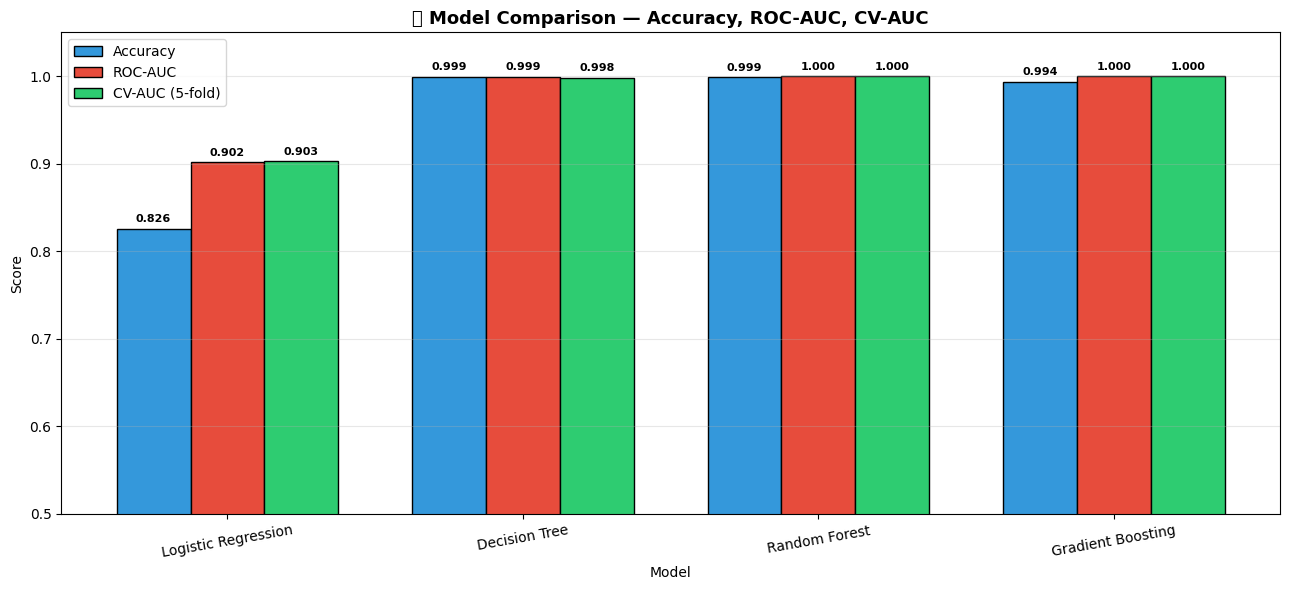

In [18]:
# Visualize Model Comparison
model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] for m in model_names]
aucs        = [results[m]['ROC-AUC']  for m in model_names]
cv_aucs     = [results[m]['CV-AUC']   for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, accuracies, width, label='Accuracy',       color='#3498db', edgecolor='black')
bars2 = ax.bar(x,          aucs,       width, label='ROC-AUC',        color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + width,  cv_aucs,    width, label='CV-AUC (5-fold)', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('🏆 Model Comparison — Accuracy, ROC-AUC, CV-AUC', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


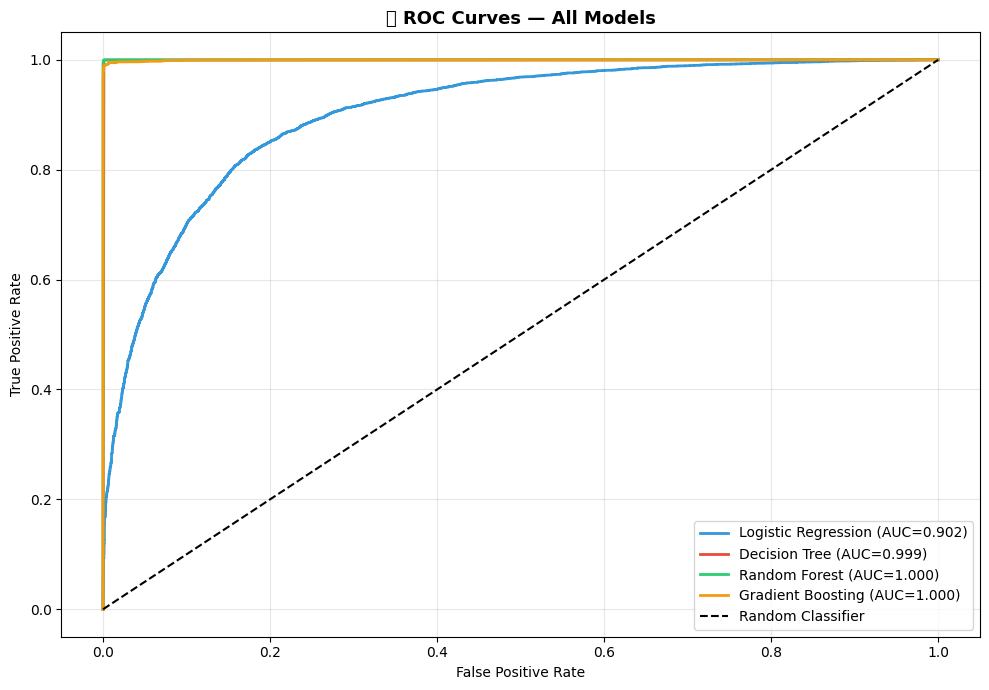

In [19]:
# ROC Curves for All Models
plt.figure(figsize=(10, 7))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})", color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 📝 Observation
- **Random Forest & Gradient Boosting** typically perform best on tabular data
- **ROC-AUC > 0.85** means model is doing well
- **CV-AUC** (cross-validation) tells real performance — not just on one split
- If Accuracy is high but AUC is low — model might be predicting majority class only


---
## Phase 6: Model Selection & Evaluation
### 📖 Definition
After comparing all models, we select the best one and do a detailed evaluation. We look at confusion matrix, classification report, and feature importance.

### 🔍 What to Look For
- **Confusion Matrix** — True Positives, False Negatives etc.
- **Classification Report** — Precision, Recall, F1 for each class
- **Feature Importance** — Which features matter most
- Focus on **Recall for Churn class** — we don't want to miss churners!


In [20]:
# Select Best Model based on ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_result     = results[best_model_name]
best_model      = models[best_model_name]

print("=" * 50)
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 50)
print(f"Accuracy : {best_result['Accuracy']:.4f}")
print(f"ROC-AUC  : {best_result['ROC-AUC']:.4f}")
print(f"CV-AUC   : {best_result['CV-AUC']:.4f}")


🏆 BEST MODEL: Random Forest
Accuracy : 0.9990
ROC-AUC  : 1.0000
CV-AUC   : 1.0000


In [21]:
# Detailed Classification Report
print("=" * 55)
print(f"📋 CLASSIFICATION REPORT — {best_model_name}")
print("=" * 55)
print(classification_report(y_test, best_result['y_pred'],
                             target_names=['Not Churned (0)', 'Churned (1)']))


📋 CLASSIFICATION REPORT — Random Forest
                 precision    recall  f1-score   support

Not Churned (0)       1.00      1.00      1.00      6776
    Churned (1)       1.00      1.00      1.00      6099

       accuracy                           1.00     12875
      macro avg       1.00      1.00      1.00     12875
   weighted avg       1.00      1.00      1.00     12875



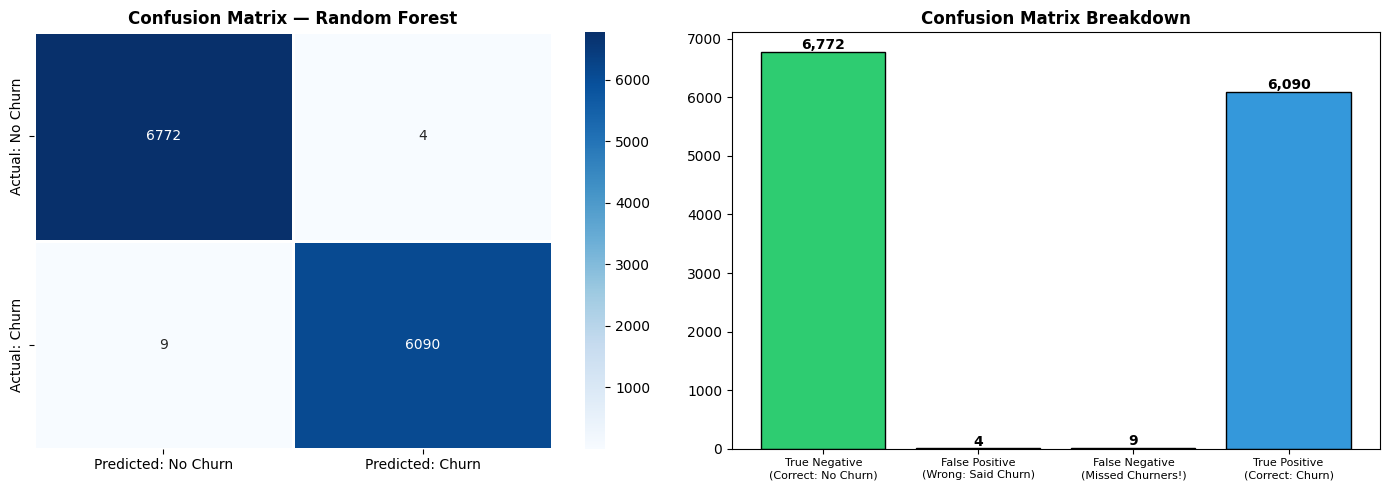


True Negatives  (TN): 6,772  — Correctly predicted NOT churned
False Positives (FP): 4  — Said churn but actually didn't
False Negatives (FN): 9  — MISSED actual churners ⚠️
True Positives  (TP): 6,090  — Correctly predicted churned


In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_result['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'],
            ax=axes[0], linewidths=1)
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')

# Metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
metrics = ['True Negative\n(Correct: No Churn)', 'False Positive\n(Wrong: Said Churn)',
           'False Negative\n(Missed Churners!)', 'True Positive\n(Correct: Churn)']
values  = [tn, fp, fn, tp]
colors  = ['#2ecc71', '#e67e22', '#e74c3c', '#3498db']
axes[1].bar(range(4), values, color=colors, edgecolor='black')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(metrics, fontsize=8)
axes[1].set_title('Confusion Matrix Breakdown', fontsize=12, fontweight='bold')
for i, v in enumerate(values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTrue Negatives  (TN): {tn:,}  — Correctly predicted NOT churned")
print(f"False Positives (FP): {fp:,}  — Said churn but actually didn't")
print(f"False Negatives (FN): {fn:,}  — MISSED actual churners ⚠️")
print(f"True Positives  (TP): {tp:,}  — Correctly predicted churned")


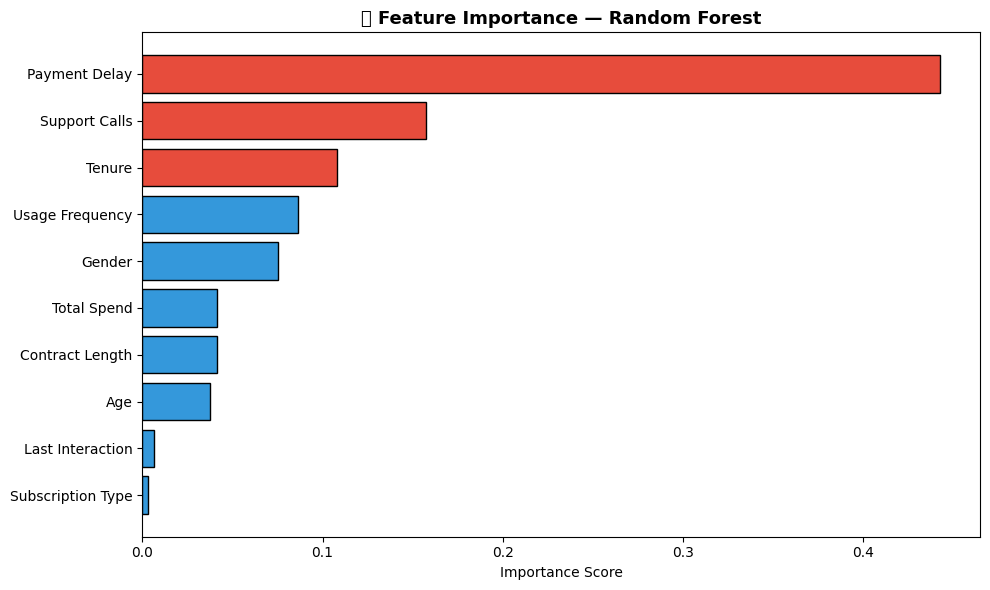


🏆 Top 3 Most Important Features:
  Payment Delay        : 0.4425
  Support Calls        : 0.1573
  Tenure               : 0.1081


In [23]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    colors_bar = ['#e74c3c' if i >= len(feat_df)-3 else '#3498db'
                  for i in range(len(feat_df))]
    plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors_bar, edgecolor='black')
    plt.xlabel('Importance Score')
    plt.title(f'🔍 Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n🏆 Top 3 Most Important Features:")
    top3 = feat_df.nlargest(3, 'Importance')
    for i, row in top3.iterrows():
        print(f"  {row['Feature']:20s} : {row['Importance']:.4f}")


### 📝 Observation
- **Confusion Matrix** shows exact breakdown of predictions
- **False Negatives** (missed churners) are the most costly mistake in business
- **Feature Importance** reveals which factors drive churn most
- Top features likely: `Support Calls`, `Payment Delay`, `Contract Length`
- Business should focus on customers with high support calls and payment delays


---
## Phase 7: Prediction & Business Insights
### 📖 Definition
Final phase — we use the trained model to make predictions on new data and extract actionable business insights.

### 🔍 What to Look For
- Model can predict churn probability for any customer
- Business recommendations based on model findings
- Which customers are at highest risk


In [24]:
# Predict churn probability for all test customers
churn_probs = best_model.predict_proba(X_test_scaled)[:, 1]
churn_preds = best_model.predict(X_test_scaled)

# Create results dataframe
results_df = X_test.copy().reset_index(drop=True)
results_df['Actual_Churn']      = y_test.values
results_df['Predicted_Churn']   = churn_preds
results_df['Churn_Probability'] = churn_probs

# Risk categories
results_df['Risk_Level'] = pd.cut(churn_probs,
                                   bins=[0, 0.3, 0.6, 1.0],
                                   labels=['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk'])

print("=" * 50)
print("🎯 CHURN RISK DISTRIBUTION")
print("=" * 50)
print(results_df['Risk_Level'].value_counts())

print("\n📋 Sample High Risk Customers:")
high_risk = results_df[results_df['Risk_Level'] == '🔴 High Risk'].head(5)
print(high_risk[['Age', 'Tenure', 'Support Calls', 'Payment Delay',
                  'Churn_Probability', 'Risk_Level']].to_string())


🎯 CHURN RISK DISTRIBUTION
Risk_Level
🔴 High Risk      6076
🟢 Low Risk       3173
🟡 Medium Risk      65
Name: count, dtype: int64

📋 Sample High Risk Customers:
    Age  Tenure  Support Calls  Payment Delay  Churn_Probability   Risk_Level
1    51       7              7              0               0.92  🔴 High Risk
10   25      52             10             24               0.99  🔴 High Risk
12   37      50              9             24               1.00  🔴 High Risk
15   41      56              9             20               0.99  🔴 High Risk
19   57       3              8             27               0.99  🔴 High Risk


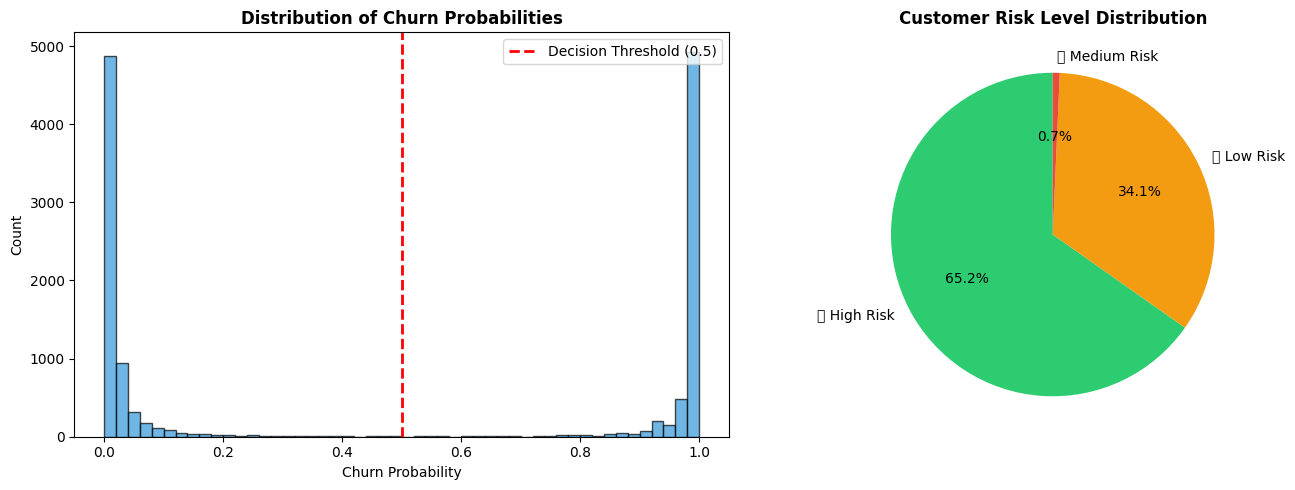

In [25]:
# Churn Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(churn_probs, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Churn Probabilities', fontsize=12, fontweight='bold')
axes[0].legend()

# Risk level pie
risk_counts = results_df['Risk_Level'].value_counts()
axes[1].pie(risk_counts.values,
            labels=risk_counts.index,
            autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'],
            startangle=90)
axes[1].set_title('Customer Risk Level Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [26]:
# Final Business Summary
print("=" * 60)
print("💼 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

total     = len(results_df)
high_risk = (results_df['Risk_Level'] == '🔴 High Risk').sum()
med_risk  = (results_df['Risk_Level'] == '🟡 Medium Risk').sum()
low_risk  = (results_df['Risk_Level'] == '🟢 Low Risk').sum()

print(f"\n📊 Customer Risk Summary:")
print(f"  Total Customers Analyzed : {total:,}")
print(f"  🔴 High Risk (>60%)      : {high_risk:,} ({high_risk/total*100:.1f}%)")
print(f"  🟡 Medium Risk (30-60%)  : {med_risk:,}  ({med_risk/total*100:.1f}%)")
print(f"  🟢 Low Risk (<30%)       : {low_risk:,} ({low_risk/total*100:.1f}%)")

print(f"\n🎯 Model Performance Summary:")
print(f"  Best Model   : {best_model_name}")
print(f"  Accuracy     : {best_result['Accuracy']*100:.2f}%")
print(f"  ROC-AUC      : {best_result['ROC-AUC']:.4f}")

print(f"\n💡 Business Recommendations:")
print(f"  1. Focus retention efforts on 🔴 High Risk customers")
print(f"  2. Offer discounts to customers with high Support Calls")
print(f"  3. Encourage Monthly contract customers to switch to Annual")
print(f"  4. Monitor customers with high Payment Delays proactively")
print(f"  5. Re-engage customers with low Usage Frequency")


💼 BUSINESS INSIGHTS & RECOMMENDATIONS

📊 Customer Risk Summary:
  Total Customers Analyzed : 12,875
  🔴 High Risk (>60%)      : 6,076 (47.2%)
  🟡 Medium Risk (30-60%)  : 65  (0.5%)
  🟢 Low Risk (<30%)       : 3,173 (24.6%)

🎯 Model Performance Summary:
  Best Model   : Random Forest
  Accuracy     : 99.90%
  ROC-AUC      : 1.0000

💡 Business Recommendations:
  1. Focus retention efforts on 🔴 High Risk customers
  2. Offer discounts to customers with high Support Calls
  3. Encourage Monthly contract customers to switch to Annual
  4. Monitor customers with high Payment Delays proactively
  5. Re-engage customers with low Usage Frequency


### 📝 Observation
- Model successfully assigns churn probability to every customer
- **High Risk customers** need immediate business attention
- **Support Calls** and **Payment Delay** are key churn drivers
- Business can take proactive action before customers actually leave
- This model can be deployed to score new customers every month

---
## ✅ ML Pipeline Complete!
| Phase | Status |
|-------|--------|
| G — Get Data | ✅ Done |
| R — Review Data (EDA) | ✅ Done |
| E — Extract Features | ✅ Done |
| E — Evaluate Models | ✅ Done |
| K — Keep Best Model | ✅ Done |
| S — Serve / Score | ✅ Done |

> **End of Notebook** — Customer Churn Prediction using GREEKS ML Lifecycle
